# 04. NUTS: the reference posterior and what it costs

**Goal.** Certify a reference posterior for the repaired (innovations
form) model, adjudicate the two ADVI surrogates against it, price the
warm starts, isolate what the heteroskedastic head buys via the
homoskedastic ablation and settle the GPU-versus-CPU question for both
likelihood formulations. Reads the artifacts of
`scripts/fit_bsts_innovations.py` and `scripts/fit_bsts_collapsed.py`.

One result reshapes the whole notebook: cold NUTS on the innovations
model does not mix, from any reasonable warmup budget, because the
posterior has degenerate basins that dispersed chains fall into and
cannot leave. The ADVI warm start is therefore not an economy here, it
is what makes NUTS work at all. The trend model's collapsed likelihood
had the opposite profile: an expensive sequential gradient but a
geometry cold NUTS handled cleanly. The two formulations together make
the general point that likelihood design buys speed or robustness, and
sometimes trades one for the other.

In [1]:
import json
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")  # notebook JAX work is light; leave the GPU to fits

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nemforecastdemand.config import load_config
from nemforecastdemand.evaluation.diagnostics import time_to_target_ess
from nemforecastdemand.evaluation.metrics import crps_samples
from nemforecastdemand.plotting import palette, save_figure, setup_style
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()

cold, cold_meta = load_artifact(cfg.paths.artifacts / "bsts_innovations_nuts_cold")
reference, reference_meta = load_artifact(
    cfg.paths.artifacts / "bsts_innovations_nuts_warm_fullrank_w300"
)
homo, homo_meta = load_artifact(cfg.paths.artifacts / "bsts_innovations_nuts_homoskedastic")
vi_fits = {
    kind: load_artifact(cfg.paths.artifacts / f"bsts_innovations_vi_{kind}")
    for kind in ("meanfield", "fullrank")
}
chain_colours = ["#1f5673", "#7a4988", "#c44536", "#e8a13a"]

## Cold NUTS finds three posteriors, none of them useful together

Four chains from dispersed inits, the standard warmup budget. Each chain
mixes within itself and they disagree wildly: split R-hat in the fives,
bulk ESS of four. The per-chain means show why. There is an all-noise
basin (large $\gamma_0$: inflate the innovation scale and the regression
stops mattering), a near-unit-root ridge ($\rho \to 1$: differencing
erases the regression signal, leaving $\beta$ unidentified) and the data-
preferred mode. Tripling the warmup reproduces the same picture with
zero divergences, so this is geometry, not adaptation failure.

In [2]:
pd.DataFrame(cold_meta["site_summary"]).set_index("site").round(3)

,size,max_rhat,min_bulk_ess,min_tail_ess
site,,,,
beta,54,4.515,4.263,4.424
gamma,8,4.318,4.268,4.589
gamma0,1,3.750,4.360,4.723
rho,1,3.697,4.366,4.587


In [3]:
pd.DataFrame(
    {
        "rho": cold["post_rho"].mean(axis=1).round(4),
        "gamma0": cold["post_gamma0"].mean(axis=1).round(3),
        "rho sd": cold["post_rho"].std(axis=1).round(5),
    }
).rename_axis("chain")

,rho,gamma0,rho sd
chain,,,
0,0.8452,0.726,0.00008
1,0.9621,-0.956,0.00000
2,0.8665,0.985,0.00002
3,0.6745,1.238,0.00024


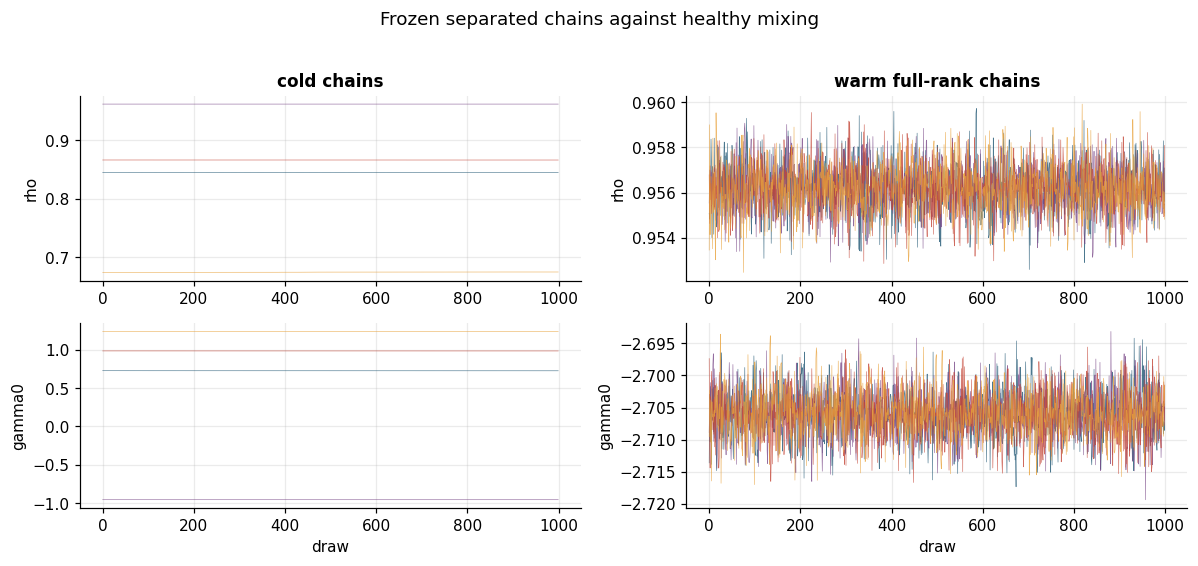

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for col, (label, arrays) in enumerate((("cold", cold), ("warm full-rank", reference))):
    for row, site in enumerate(("rho", "gamma0")):
        draws = arrays[f"post_{site}"]
        for chain in range(draws.shape[0]):
            axes[row, col].plot(draws[chain], lw=0.4, color=chain_colours[chain], alpha=0.8)
        axes[row, col].set_ylabel(site)
    axes[0, col].set_title(f"{label} chains")
axes[-1, 0].set_xlabel("draw")
axes[-1, 1].set_xlabel("draw")
fig.suptitle("Frozen separated chains against healthy mixing", y=1.02)
fig.tight_layout()
save_figure(fig, "nuts_traces", cfg.paths.figures)
plt.show()

## Adjudicating the basins by log density

The basins are not equally good explanations; the joint log density at
each cold chain's mean settles their ranking against the warm reference.
The degenerate basins sit catastrophically far below the mode the warm
start finds, so the cold chains are stuck in regions the posterior
barely supports. They are local traps, not competing explanations.

In [5]:
from functools import partial

import jax.numpy as jnp
from numpyro.infer.util import log_density

from nemforecastdemand.data.loaders import load_panel, load_splits
from nemforecastdemand.models import bsts, innovations
from nemforecastdemand.splits import rolling_origins

panel = load_panel(cfg.paths.processed)
splits = load_splits(cfg.paths.processed)
max_lag = max(cfg.features.demand_lags)
fit_index = splits["train"].index[max_lag:]
inputs = bsts.prepare_inputs(panel, cfg, fit_index)
test_origins = rolling_origins(splits["test"].index, panel.index, cfg.origins, cfg.horizon, max_lag)
model_args = (
    jnp.asarray(inputs.y),
    jnp.asarray(inputs.x_mean),
    jnp.asarray(inputs.x_var),
    cfg.bsts,
)
AR_SITES = ("rho", "beta", "gamma0", "gamma")


def joint_log_density(arrays: dict, chain: int) -> float:
    params = {
        name: jnp.asarray(arrays[f"post_{name}"][chain].mean(axis=0)) for name in AR_SITES
    }
    value, _ = log_density(innovations.innovations_model, model_args, {}, params)
    return float(value)


rows = {
    f"cold chain {chain}": {
        "rho": float(cold["post_rho"][chain].mean()),
        "gamma0": float(cold["post_gamma0"][chain].mean()),
        "log density at chain mean": joint_log_density(cold, chain),
    }
    for chain in range(cold["post_rho"].shape[0])
}
rows["warm reference"] = {
    "rho": float(reference["post_rho"].mean()),
    "gamma0": float(reference["post_gamma0"].mean()),
    "log density at chain mean": joint_log_density(reference, 0),
}
pd.DataFrame(rows).T.round(2)

/home/s95717/miniforge3/envs/nem-demand-forecast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,rho,gamma0,log density at chain mean
cold chain 0,0.85,0.73,-74035.28
cold chain 1,0.96,-0.96,-17231.03
cold chain 2,0.87,0.98,-83501.74
cold chain 3,0.67,1.24,-93199.91
warm reference,0.96,-2.71,45577.14


## The reference posterior

The reference run seeds chains from the full-rank surrogate with its
covariance frozen as the inverse mass matrix and 300 warmup steps. Its
diagnostics are what cold NUTS could not deliver. Two independent
checks say this is the real posterior and not a guide-induced
artefact: warm chains seeded from the *mean-field* guide (different
family, diagonal mass matrix) land on the same distribution, and the
cold log-density table above puts every alternative basin far below it.

In [6]:
summary = pd.DataFrame(reference_meta["site_summary"]).set_index("site")
health = pd.DataFrame(reference_meta["chain_health"]).set_index("chain")
print(summary.round(4).to_string())
health.round(3)

        size  max_rhat  min_bulk_ess  min_tail_ess
site                                              
beta      54    1.0048     4690.7535     2526.2335
gamma      8    1.0042     4883.0668     2822.1035
gamma0     1    1.0023     5039.4212     2822.0885
rho        1    1.0013     5133.3768     2676.4553


,divergences,e_bfmi,tree_depth_saturation
chain,,,
0,0,0.937,0.0
1,0,0.991,0.0
2,0,1.025,0.0
3,0,1.046,0.0


In [7]:
warm_mf, _ = load_artifact(cfg.paths.artifacts / "bsts_innovations_nuts_warm_meanfield_w300")
agreement = {}
for site in ("rho", "gamma0"):
    fr = reference[f"post_{site}"].ravel()
    mf = warm_mf[f"post_{site}"].ravel()
    agreement[site] = {
        "mean (warm from FR)": fr.mean(),
        "mean (warm from MF)": mf.mean(),
        "abs mean gap / posterior sd": abs(fr.mean() - mf.mean()) / fr.std(),
    }
pd.DataFrame(agreement).T.round(4)

,mean (warm from FR),mean (warm from MF),abs mean gap / posterior sd
rho,0.9562,0.9562,0.0001
gamma0,-2.7060,-2.7061,0.0253


## ADVI against the reference

Marginals, then the spread ratios. The classic mean-field failure is
under-dispersion on correlated coordinates; full-rank should track the
reference closely at fifty dimensions.

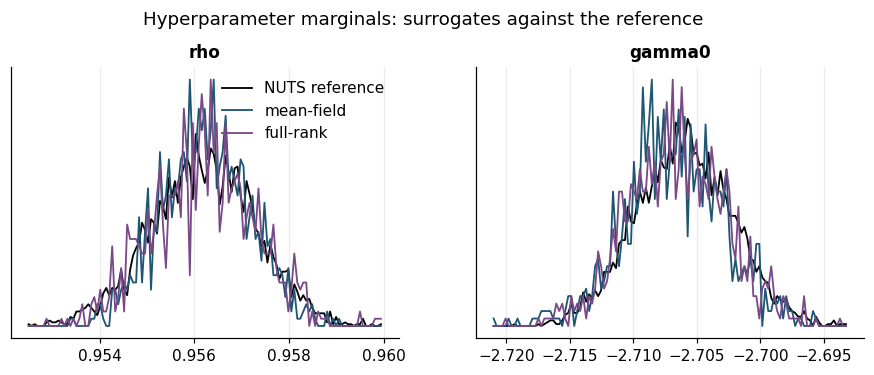

In [8]:
compare_sites = ["rho", "gamma0"]
fig, axes = plt.subplots(1, len(compare_sites), figsize=(10, 3.2))
for ax, site in zip(axes, compare_sites, strict=True):
    nuts_draws = reference[f"post_{site}"].ravel()
    grid_lo = min(nuts_draws.min(), *(fit[0][f"draw_{site}"].min() for fit in vi_fits.values()))
    grid_hi = max(nuts_draws.max(), *(fit[0][f"draw_{site}"].max() for fit in vi_fits.values()))
    grid = np.linspace(grid_lo, grid_hi, 120)
    for label, draws, colour in (
        ("NUTS reference", nuts_draws, "black"),
        ("mean-field", vi_fits["meanfield"][0][f"draw_{site}"], palette("demand")),
        ("full-rank", vi_fits["fullrank"][0][f"draw_{site}"], palette("accent")),
    ):
        density = np.histogram(draws, bins=grid, density=True)[0]
        centres = (grid[:-1] + grid[1:]) / 2
        ax.plot(centres, density, label=label, color=colour, lw=1.2)
    ax.set_title(site)
    ax.set_yticks([])
axes[0].legend()
fig.suptitle("Hyperparameter marginals: surrogates against the reference", y=1.04)
save_figure(fig, "advi_vs_nuts_marginals", cfg.paths.figures)
plt.show()

In [9]:
rows = {}
beta_ref = reference["post_beta"].reshape(-1, reference["post_beta"].shape[-1])
for site in ("rho", "gamma0"):
    nuts_sd = reference[f"post_{site}"].ravel().std()
    rows[site] = {
        "sd NUTS": nuts_sd,
        "sd MF / NUTS": vi_fits["meanfield"][0][f"draw_{site}"].std() / nuts_sd,
        "sd FR / NUTS": vi_fits["fullrank"][0][f"draw_{site}"].std() / nuts_sd,
    }
beta_sd_ref = beta_ref.std(axis=0)
rows["beta (median over 41)"] = {
    "sd NUTS": float(np.median(beta_sd_ref)),
    "sd MF / NUTS": float(
        np.median(vi_fits["meanfield"][0]["draw_beta"].std(axis=0) / beta_sd_ref)
    ),
    "sd FR / NUTS": float(
        np.median(vi_fits["fullrank"][0]["draw_beta"].std(axis=0) / beta_sd_ref)
    ),
}
pd.DataFrame(rows).T.round(3)

,sd NUTS,sd MF / NUTS,sd FR / NUTS
rho,0.001,0.845,0.976
gamma0,0.004,1.023,1.005
beta (median over 41),0.004,0.641,1.003


## Predictions and the epistemic share, three inferences side by side

Same prediction pipeline, same test origins, archived forecast weather.
The decomposition has two components for this model (the origin residual
is observed, so there is no state term); the parameter share is the
epistemic fraction, and a surrogate that under-disperses must
under-state it.

In [10]:
from nemforecastdemand.models.predict import variance_decomposition_innovations

y_test = reference["y_test"]
nuts_flat = {
    name: reference[f"post_{name}"].reshape(-1, *reference[f"post_{name}"].shape[2:])
    for name in AR_SITES
}
keep = max(nuts_flat["rho"].shape[0] // 1000, 1)
draw_sets = {
    "NUTS reference": {name: value[::keep] for name, value in nuts_flat.items()},
    "mean-field": {name: vi_fits["meanfield"][0][f"draw_{name}"] for name in AR_SITES},
    "full-rank": {name: vi_fits["fullrank"][0][f"draw_{name}"] for name in AR_SITES},
}

crps_rows = {}
for label, paths in (
    ("NUTS reference", reference["forecast_paths"]),
    ("ADVI mean-field", vi_fits["meanfield"][0]["forecast_paths"]),
    ("ADVI full-rank", vi_fits["fullrank"][0]["forecast_paths"]),
):
    crps_rows[label] = np.mean(
        [crps_samples(y_test[i], paths[:, i, :]).mean() for i in range(y_test.shape[0])]
    )
pd.Series(crps_rows, name="test CRPS (MW)").to_frame().round(1)

,test CRPS (MW)
NUTS reference,271.8
ADVI mean-field,271.6
ADVI full-rank,272.2


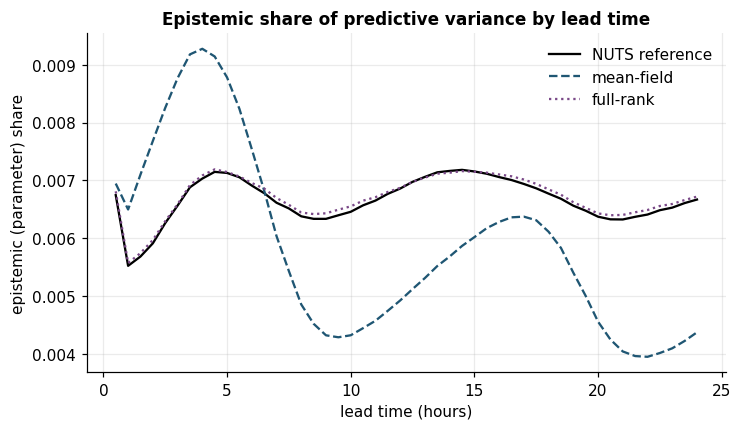

In [11]:
decomp = {
    label: variance_decomposition_innovations(draws, inputs, panel, cfg, test_origins)
    for label, draws in draw_sets.items()
}
hours = (np.arange(cfg.horizon) + 1) / 2

fig, ax = plt.subplots(figsize=(7.5, 4))
styles = {"NUTS reference": "-", "mean-field": "--", "full-rank": ":"}
colours_d = {
    "NUTS reference": "black",
    "mean-field": palette("demand"),
    "full-rank": palette("accent"),
}
for label, parts in decomp.items():
    total = parts["parameter"] + parts["innovation"]
    ax.plot(
        hours,
        (parts["parameter"] / total).mean(axis=0),
        ls=styles[label],
        color=colours_d[label],
        label=label,
    )
ax.set_xlabel("lead time (hours)")
ax.set_ylabel("epistemic (parameter) share")
ax.set_title("Epistemic share of predictive variance by lead time")
ax.legend()
save_figure(fig, "collapsed_variance_decomposition", cfg.paths.figures)
plt.show()

In [12]:
rows = {}
for label, parts in decomp.items():
    total = parts["parameter"] + parts["innovation"]
    rows[label] = {
        "parameter share": float((parts["parameter"] / total).mean()),
        "innovation share": float((parts["innovation"] / total).mean()),
        "mean predictive sd (MW)": float(np.sqrt(total.mean())),
    }
pd.DataFrame(rows).T.round(3)

,parameter share,innovation share,mean predictive sd (MW)
NUTS reference,0.007,0.993,373.561
mean-field,0.006,0.994,373.190
full-rank,0.007,0.993,373.223


## The homoskedastic ablation

Identical model with the variance head switched off: one constant
innovation scale, the same noise structure ARIMA uses. Warm started the
same way (its cold chains fall into the same traps). The comparison
isolates what covariate-driven spread buys; notebook 05 carries both
rows into the cross-model table with calibration alongside.

In [13]:
rows = {
    "heteroskedastic": {
        "rho": float(reference["post_rho"].mean()),
        "max R-hat": reference_meta["max_rhat"],
        "test CRPS (MW)": float(crps_rows["NUTS reference"]),
    },
    "homoskedastic ablation": {
        "rho": float(homo["post_rho"].mean()),
        "max R-hat": homo_meta["max_rhat"],
        "test CRPS (MW)": float(
            np.mean(
                [
                    crps_samples(y_test[i], homo["forecast_paths"][:, i, :]).mean()
                    for i in range(y_test.shape[0])
                ]
            )
        ),
    },
}
pd.DataFrame(rows).T.round(3)

,rho,max R-hat,test CRPS (MW)
heteroskedastic,0.956,1.005,271.756
homoskedastic ablation,0.981,1.013,284.553


## Pricing the warm start

Strict accounting at matched quality: cold total is full warmup plus
sampling; warm total adds the ADVI fit it depends on. Quality means
bulk ESS at the target with R-hat under threshold and no divergences;
a run that misses quality is unfinished, not fast. For this model the
cold rows fail outright, which changes the conclusion from "warm starts
are cheaper" to "warm starts are how NUTS gets a posterior here at all".

In [14]:
target = cfg.warm_start.target_bulk_ess
runs = {"cold": cold_meta}
for kind in ("meanfield", "fullrank"):
    for reduced in cfg.warm_start.reduced_warmup:
        stem = f"bsts_innovations_nuts_warm_{kind}_w{reduced}"
        runs[f"warm {kind} w={reduced}"] = load_artifact(cfg.paths.artifacts / stem)[1]

rows = {}
for name, meta in runs.items():
    run_timing = meta["timings_seconds"]
    advi_seconds = meta.get("advi_seconds", 0.0)
    to_target = time_to_target_ess(
        run_timing["warmup_seconds"], run_timing["sample_seconds"], meta["min_bulk_ess"], target
    )
    quality_ok = meta["max_rhat"] < cfg.warm_start.rhat_threshold and meta["total_divergences"] == 0
    rows[name] = {
        "ADVI (s)": advi_seconds,
        "warmup (s)": run_timing["warmup_seconds"],
        "sampling (s)": run_timing["sample_seconds"],
        "min bulk ESS": meta["min_bulk_ess"],
        "max R-hat": meta["max_rhat"],
        "divergences": meta["total_divergences"],
        f"total to ESS {target:.0f} (s)": advi_seconds + to_target,
        "quality met": quality_ok,
    }
warm_table = pd.DataFrame(rows).T
warm_table.round(3)

,ADVI (s),warmup (s),sampling (s),min bulk ESS,max R-hat,divergences,total to ESS 400 (s),quality met
cold,0.0,102.564745,101.174987,4.262681,4.514617,0,9596.588566,False
warm meanfield w=100,3.023073,6.037856,5.343621,517.240929,1.012237,0,13.193332,False
warm meanfield w=300,3.023073,4.486939,5.096265,531.304732,1.0042,0,11.346804,True
warm fullrank w=100,3.775842,4.00183,2.225326,5607.279791,1.005263,0,7.936417,True
warm fullrank w=300,3.775842,3.549872,3.041215,4690.753535,1.004839,0,7.58505,True


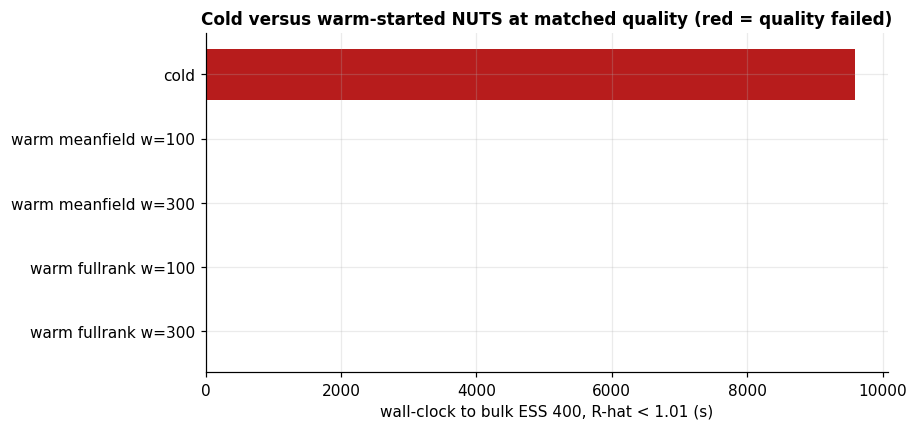

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
column = f"total to ESS {target:.0f} (s)"
bars = warm_table[column].astype(float)
colours_bar = ["#2e7d32" if ok else "#b71c1c" for ok in warm_table["quality met"]]
ax.barh(bars.index[::-1], bars[::-1], color=colours_bar[::-1])
ax.set_xlabel(f"wall-clock to bulk ESS {target:.0f}, R-hat < {cfg.warm_start.rhat_threshold} (s)")
ax.set_title("Cold versus warm-started NUTS at matched quality (red = quality failed)")
save_figure(fig, "warm_start_accounting", cfg.paths.figures)
plt.show()

For completeness, the trend model told the opposite story: its collapsed
likelihood mixed cleanly from cold (max R-hat about 1.01, no divergences)
and the warm start was an economy rather than a necessity, cutting
wall-clock to the ESS target by several-fold.

## GPU against CPU

The innovations likelihood is pure matrix arithmetic, so it was fitted on
the GPU and rerun on the CPU with identical code and timing barriers; the
GPU wins throughout and both devices finish in seconds. The collapsed
likelihood is the opposite case: a sequential scan inside every gradient.
It is fitted on the CPU (chains in parallel across cores), and the GPU is
tried only as a benchmark, capped at 2,000 ADVI steps so the per-step
rate is comparable. The scan is so hostile to the GPU that the sampler's
kernel does not even compile there; only the variational fits run, and
slowly. Likelihood design, not hardware, is the binding constraint.

In [16]:
def wall_seconds(meta: dict) -> float:
    t = meta["timings_seconds"]
    if "fit_seconds" in t:
        return t["fit_seconds"]
    return t["warmup_seconds"] + t["sample_seconds"]


def steps_per_second(meta: dict) -> float:
    return meta["timings_seconds"].get("steps_per_second", float("nan"))


# Innovations: GPU is the primary fit, CPU the sidecar.
innov_stems = {
    "ADVI mean-field": "bsts_innovations_vi_meanfield",
    "ADVI full-rank": "bsts_innovations_vi_fullrank",
}
for kind in ("meanfield", "fullrank"):
    for reduced in cfg.warm_start.reduced_warmup:
        innov_stems[f"NUTS warm {kind} w={reduced}"] = (
            f"bsts_innovations_nuts_warm_{kind}_w{reduced}"
        )
innov_rows = {}
for label, stem in innov_stems.items():
    gpu = json.loads((cfg.paths.artifacts / f"{stem}.json").read_text())
    cpu = json.loads((cfg.paths.artifacts / f"{stem}.cpu.json").read_text())
    gpu_s, cpu_s = wall_seconds(gpu), wall_seconds(cpu)
    innov_rows[label] = {"GPU (s)": gpu_s, "CPU (s)": cpu_s, "GPU speed-up": cpu_s / gpu_s}
print("Innovations model: GPU against CPU (seconds)")
print(pd.DataFrame(innov_rows).T.round(2).to_string())

Innovations model: GPU against CPU (seconds)
                           GPU (s)  CPU (s)  GPU speed-up
ADVI mean-field               3.02    25.18          8.33
ADVI full-rank                3.78    29.46          7.80
NUTS warm meanfield w=100    11.38    15.15          1.33
NUTS warm meanfield w=300     9.58    16.06          1.68
NUTS warm fullrank w=100      6.23     9.68          1.55
NUTS warm fullrank w=300      6.59     9.94          1.51


The collapsed model is fitted on the CPU. The table below compares the
variational per-step rate on CPU against the capped GPU benchmark, and
records which collapsed fits the GPU backend refused to compile.

In [17]:
collapsed_rows = {}
for label, stem in (
    ("ADVI mean-field", "bsts_collapsed_vi_meanfield"),
    ("ADVI full-rank", "bsts_collapsed_vi_fullrank"),
):
    cpu = json.loads((cfg.paths.artifacts / f"{stem}.json").read_text())
    gpu_path = cfg.paths.artifacts / f"{stem}.gpu.json"
    row = {"CPU steps/s": steps_per_second(cpu), "CPU fit (s)": wall_seconds(cpu)}
    if gpu_path.exists():
        gpu = json.loads(gpu_path.read_text())
        row["GPU steps/s"] = steps_per_second(gpu) if "timings_seconds" in gpu else float("nan")
        row["GPU compiled"] = "timings_seconds" in gpu
    collapsed_rows[label] = row
nuts_compiled = {}
for stem in ("bsts_collapsed_nuts_cold", "bsts_collapsed_nuts_warm_fullrank_w300"):
    gpu_path = cfg.paths.artifacts / f"{stem}.gpu.json"
    if gpu_path.exists():
        gpu = json.loads(gpu_path.read_text())
        nuts_compiled[stem] = "compiled" if "timings_seconds" in gpu else "compile FAILED"
print("Collapsed model: CPU fit against GPU benchmark")
print(pd.DataFrame(collapsed_rows).T.round(3).to_string())
print("\nCollapsed NUTS on GPU:", nuts_compiled or "benchmark not run")

Collapsed model: CPU fit against GPU benchmark
                CPU steps/s  CPU fit (s) GPU steps/s GPU compiled
ADVI mean-field   13.400876  1492.365158    2.521153         True
ADVI full-rank    13.371862   1495.60326    2.523845         True

Collapsed NUTS on GPU: {'bsts_collapsed_nuts_cold': 'compile FAILED', 'bsts_collapsed_nuts_warm_fullrank_w300': 'compile FAILED'}


## Summary

- Cold NUTS on the innovations model is defeated by degenerate basins
  (all-noise and near-unit-root); the log-density table shows they are
  traps, not explanations. VI locates the data-preferred mode, NUTS
  certifies it: the warm start is a necessity here, not an optimisation.
- The certified reference passes every diagnostic with thousands of
  effective samples in seconds of sampling, and two independent guide
  families warm-start to the same posterior.
- Full-rank ADVI tracks the reference closely; mean-field under-disperses
  on the correlated coordinates, visible in the sd ratios and in its
  epistemic share.
- The hardware verdict inverts with the likelihood: the Kalman scan made
  the GPU lose to the CPU, the innovations form makes everything fast
  and hands the GPU the win. The constraint was likelihood design.